# OTX2 case study — visualization tutorial

This tutorial walks through four core visual analyses a bulk
epigenomics study routinely produces, all tied to one biological
question: **where does OTX2 bind during human minor EGA, and what
does that imply for gene regulation at the 4-cell stage?**

Every figure reproduces a panel from Wang, Q. *et al.* Maternal
factor *OTX2* regulates human embryonic genome activation and early
development. *Nature Genetics* **57**, 2772–2784 (2025) —
[10.1038/s41588-025-02350-8](https://doi.org/10.1038/s41588-025-02350-8)
— but the goal here is the `epione` API, not the paper. By the end
you'll have used:

| Section | Question it answers | Core epione call |
| --- | --- | --- |
| **1 · Single-locus browser** | Does OTX2 CUT&RUN signal reproduce across replicates, and collapse on OTX2-KD? | `bigwig.plot_track` |
| **2 · Multi-locus browser** | At curated EGA genes, does OTX2 binding co-occur with open chromatin (ATAC) and active histone marks (H3K4me3 / H3K27ac)? | `bigwig.plot_track_multi` |
| **3 · Signal heatmap** | Genome-wide, which distal OTX2 peaks are cell-type-specific vs shared across 4C / ESC / dEC? | `bigwig.compute_matrix_region` + `plot_matrix_multi` |
| **4 · Motif enrichment** | Which partner TFs' motifs sit under the 4C OTX2 peaks? | `bulk.find_motifs_genome` + `pl.homer_motif_table` |

All analyses start from **cached bigwigs + peak BEDs** — epione's
proper scope is "analysis from bigwigs down", not FASTQ
preprocessing.

> **Upstream / preprocessing.** FASTQ → BAM → bigwig, MACS2 peak calling, Xia 2019 / Zou 2022 / Gifford 2013 downloads, and the one-off xlsx → TSV extractions are all documented in [`preprocess.ipynb`](preprocess.ipynb). This notebook starts from the cached inputs under `/scratch/users/steorra/data/otx2/`.

### Data availability

Primary data from the paper (Wang et al. 2025):
- **Raw sequencing**: GSA-Human `HRA006621` (controlled-access, not used here).
- **Processed bigwigs / peaks / counts**: OMIX `OMIX006476`
  ([link](https://ngdc.cncb.ac.cn/omix/view/OMIX006476)). Contains OTX2 CUT&RUN
  bigwigs (4C / 8C / KD / hESC), ATAC-seq bigwigs, and peak BEDs.
- **Supplementary tables S1-S7**: downloaded from the Nature article HTML
  (stage-activated gene lists, DEG tables, 4C OTX2 CUT&RUN peaks).

External data:
- **RNA / Ribo at pre-implantation stages** (Zou et al. 2022 *Science*): GEO
  `GSE197265` — processed bigwigs `GSE197265_h_{GV,MII,1C,2C,4C,8C,ICM}_rep12_merge_RNA_10bp_rpkm.bw`.
- **8C H3K4me3 / H3K27ac** (Xia et al. 2019 *Science*, paper ref 82): GEO
  `GSE124718` — `GSM3543863/4_hs_8cell_3PN_H3K4me3_rep{1,2}.bedGraph.gz` and
  `GSM3820010/11_hs_8cell_3PN_H3K27ac_rep{1,2}.bedGraph.gz` (we use 3PN because
  H3K27ac is only available in 3PN embryos).

Local layout used throughout these notebooks:

```
/scratch/users/steorra/data/otx2/
  OMIX006476/                 # paper's processed files
  GSE197265/                  # Zou 2022 RNA/Ribo bigwigs
  GSE124718/                  # Xia 2019 H3K4me3/H3K27ac (converted to bigwig)
  supp/supp_tables.xlsx       # paper's Supplementary Tables S1-S7
/scratch/users/steorra/data/hg19/
  hg19.fa, hg19.fa.fai, hg19.chrom.sizes
  gencode.v41lift37.annotation.gtf.gz
```


In [1]:
import os, pathlib, warnings
os.environ['PATH'] = '/scratch/users/steorra/env/omicdev/bin:' + os.environ.get('PATH', '')
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyBigWig

# Paper / external data roots
DATA         = pathlib.Path('/scratch/users/steorra/data/otx2')
OMIX         = DATA / 'OMIX006476'        # paper processed
ZOU          = DATA / 'GSE197265'         # Zou 2022 RNA/Ribo
XIA          = DATA / 'GSE124718'         # Xia 2019 8C histone
GIFFORD      = DATA / 'GSE61475'

HG19         = pathlib.Path('/scratch/users/steorra/data/hg19')
GENCODE_GTF  = HG19 / 'gencode.v41lift37.annotation.gtf.gz'
HG19_FA      = HG19 / 'hg19.fa'
HG19_SIZES   = HG19 / 'hg19.chrom.sizes'

import epione as epi
epi.pl.plot_set()
print('epione', epi.__version__ if hasattr(epi,'__version__') else 'dev')

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

epione dev


## 1 · Single-locus browser with `bigwig.plot_track`

**Biological question.** At the ZNF-cluster region on chr3
(137.7–143.3 Mb), we want to confirm four things before trusting the
OTX2 CUT&RUN data:

1. OTX2 binding is **reproducible** between CUT&RUN replicates (rep1 vs rep2).
2. The signal is **OTX2-specific** — it disappears in the OTX2-KD sample.
3. OTX2 binding is **coincident with open chromatin** (ATAC).
4. The 4C pattern is **stage-specific** — 8C and primed hESC OTX2 look different.

This is the classic UCSC-browser snapshot paradigm: stack every
condition as a horizontal row and read the picture vertically.

### The function

`fig3a_obj.plot_track(chrom, chromstart, chromend, ...)` renders one
row per bigwig registered in the `bigwig` object. All rows share the
x-axis (genomic coordinates); y-axis is the per-pixel bigwig statistic.

| Key parameter | What it controls |
| --- | --- |
| `nbins` | number of horizontal pixels. 3500 over a 5.6 Mb window ≈ 1.6 kb/bin, near-native 100-bp resolution. Alternatively pass `bp_per_bin=1600` for the same thing in bp units. |
| `value_type` | `'max'` keeps the tallest signal per bin — matches the paper's UCSC-browser aesthetic (narrow ChIP/CUT&RUN peaks stay sharp). Use `'mean'` for smoother tracks. |
| `color_dict` | `{bw_name: colour}`. Replicates should share a colour (`rep1` and `rep2` both pink) so the reader groups them visually. |
| `ymax` | **scalar** applies one limit to every row. **Dict** form `{bw_name: ymax}` gives each track its own ceiling — the paper uses hand-tuned values (e.g. 35 for rep1 vs 50 for KD) so that weaker tracks don't look flatter than they are. |
| `prefered_name` | attribute to label genes in the bottom gene track (`'gene_name'` → HGNC symbols). |

### Reading the plot

- The two OTX2 4C CUT&RUN rows (pink) should look virtually identical — that's your replicate sanity check.
- OTX2 KD (green, row 3) should collapse to background — that's the KD specificity check.
- OTX2 8C has different, sparser peaks → OTX2 targets are stage-specific.
- 4C ATAC (orange) peaks co-localize with OTX2 peaks.
- ESC OTX2 (blue, Tsankov et al. primed hESCs) shows a distinct pattern — 4C OTX2 ≠ pluripotency-stage OTX2.

└─ Load bigWig files
  ├─ Loading OTX2 4C rep1...
  ├─ Loading OTX2 4C rep2...
  ├─ Loading OTX2 KD 4C...
  ├─ Loading OTX2 8C...
  ├─ Loading 4C ATAC...
  └─ Loading ESC OTX2...
└─ Load GTF file
  ├─ Reading GTF...
  └─ Reading GTF file from /scratch/users/steorra/data/hg19/gencode.v41lift37.annotation.gtf.gz...


  └─ GTF file read successfully


  └─ GTF loaded


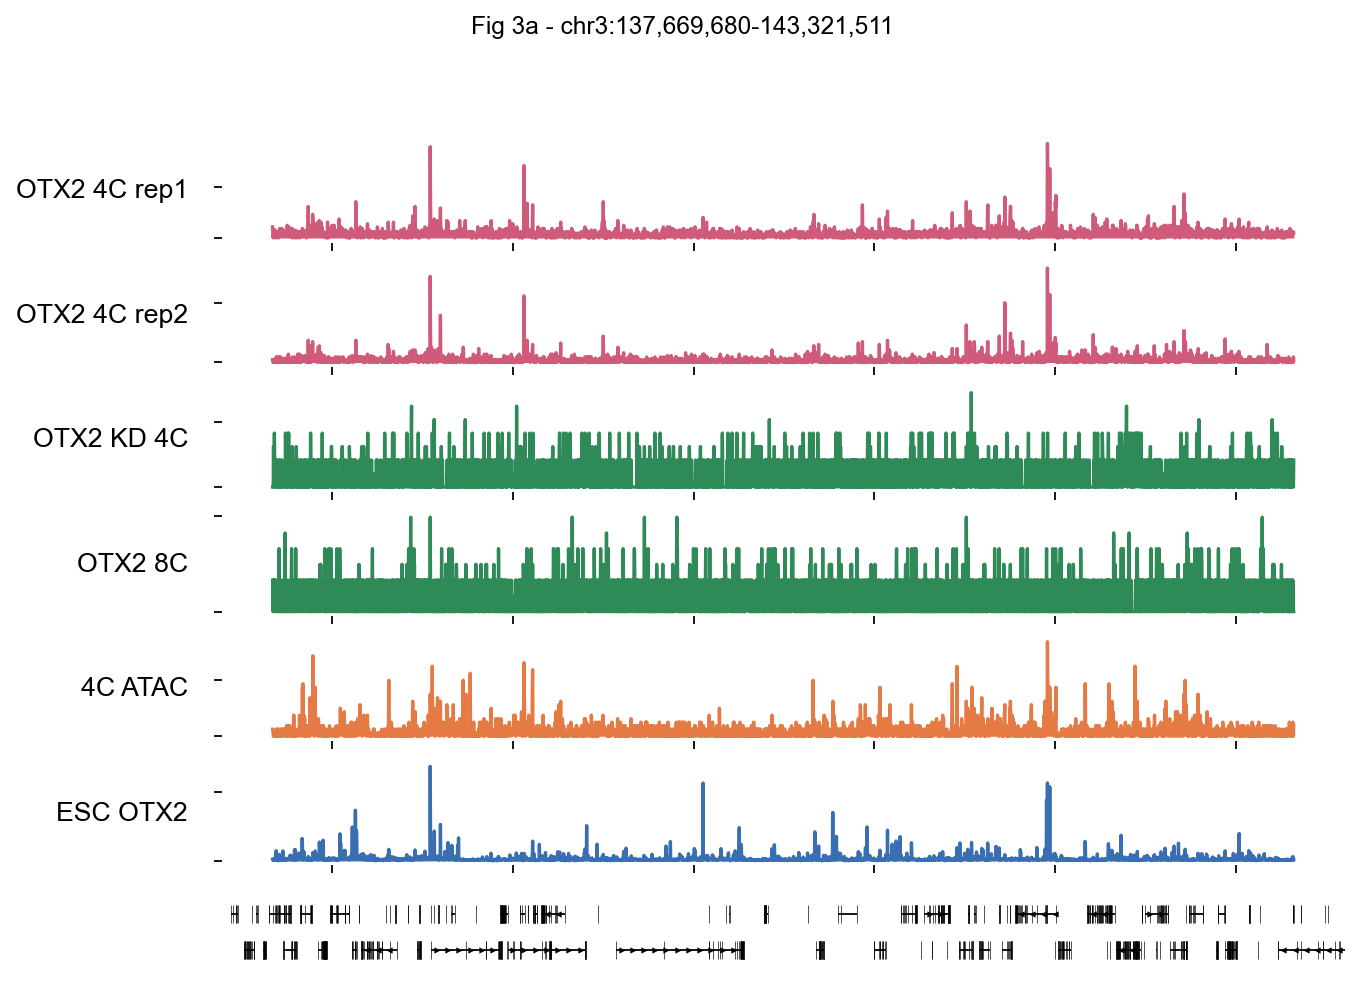

In [2]:
bw_dict = {
    'OTX2 4C rep1': str(OMIX / 'h_OTX2_day2_CUTRUN_rep1_pmu_100bp_rpkm_bamCoverage.bw'),
    'OTX2 4C rep2': str(OMIX / 'h_OTX2_day2_CUTRUN_rep2_pmu_100bp_rpkm_bamCoverage.bw'),
    'OTX2 KD 4C':   str(OMIX / 'h_OTX2_day2_CUTRUN_OTX2_KD_pmu_100bp_rpkm_bamCoverage.bw'),
    'OTX2 8C':      str(OMIX / 'h_OTX2_day3_CUTRUN_pmu_100bp_rpkm_bamCoverage.bw'),
    '4C ATAC':      str(OMIX / 'h_OTX2_ctrl_day2_ATAC_reads_count_rep1.bw'),
    'ESC OTX2':     str(OMIX / 'H9_OTX2_ChIP_21Mcells_100bp_rpkm_bamCoverage.bw'),
}
fig3a_obj = epi.bulk.bigwig(bw_dict); fig3a_obj.read()
fig3a_obj.load_gtf(str(GENCODE_GTF))

chrom, cs, ce = 'chr3', 137_669_680, 143_321_511
fig3a_obj.gtf = fig3a_obj.gtf[fig3a_obj.gtf['seqname'] == chrom].reset_index(drop=True)

color_dict = {'OTX2 4C rep1': '#CF5A79', 'OTX2 4C rep2': '#CF5A79',
              'OTX2 KD 4C':   '#2E8B57', 'OTX2 8C':      '#2E8B57',
              '4C ATAC':      '#E57A44', 'ESC OTX2':     '#3A6EB3'}

fig, axes = fig3a_obj.plot_track(
    chrom, cs, ce,
    nbins=3500, value_type='max',
    figwidth=9, figheight=6,
    color_dict=color_dict,
    prefered_name='gene_name',
    
)
fig.suptitle(f'Fig 3a - {chrom}:{cs:,}-{ce:,}', fontsize=11, y=1.02)
plt.show()


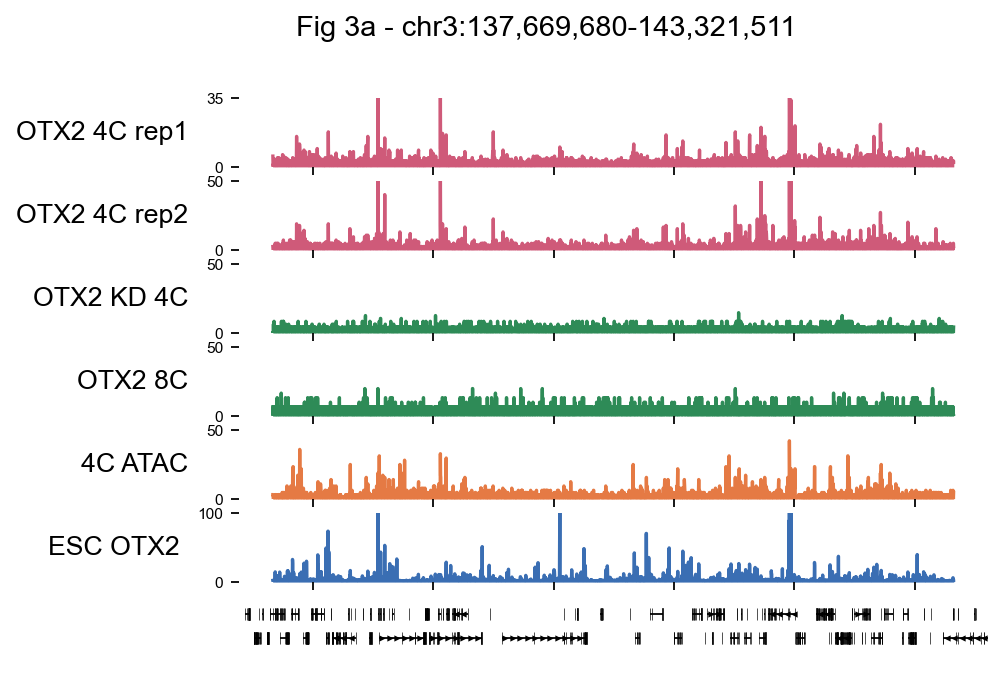

In [3]:
fig, axes = fig3a_obj.plot_track(
    chrom, cs, ce,
    nbins=3500, value_type='max',
    figwidth=6, figheight=4,
    color_dict=color_dict,
    prefered_name='gene_name',
    ymax={                                                                                                                            
          'OTX2 4C rep1': 35,                                                                                                             
          'OTX2 4C rep2': 50,                        
          'OTX2 KD 4C':   50,                                                                                                             
          'OTX2 8C':      50,                                                                                                             
          '4C ATAC':      50,                        
          'ESC OTX2':     100,                                                                                                             
      },      
)
fig.suptitle(f'Fig 3a - {chrom}:{cs:,}-{ce:,}', fontsize=13, y=1.02)
plt.show()

## 2 · Multi-locus browser with `bigwig.plot_track_multi`

**Biological question.** A single-locus browser can cherry-pick. To
argue that OTX2 drives EGA at multiple genes we need to look at
several EGA-relevant loci at once (*TPRX1/TPRX2*, *DUXB*, *TFAP2C*,
*LEUTX*, *KLF17*) plus a non-target (*EED*) and check that a
consistent pattern holds:

**OTX2 binding → open chromatin (ATAC) → active histone marks (H3K4me3 / H3K27ac at 8C) → RNA expression (FGO ↓ / 4C ↑).**

### The function

`bw.plot_track_multi(loci, bw_names=..., ...)` creates one **column**
per locus, one **row** per track. Panel widths are proportional to
each locus's genomic span, so signal density stays comparable across
panels.

| Key parameter | What it controls |
| --- | --- |
| `loci` | list of `(name, chrom, start, end)` tuples; names appear as the x-axis label under each column. |
| `bw_names` | list of tracks. **A tuple** like `('K4me3 r1', 'K4me3 r2')` averages those bigwigs per bin — the canonical way to collapse replicates without pre-merging them on disk. |
| `bp_per_bin` | bin width in bp. Smaller → more detail but spikier tracks; larger (500–1000) → smoother, less visual noise. |
| `value_type` | `'max'` or `'mean'`. `'mean'` is used here since replicates are being averaged anyway. |
| `region_dict_by_locus` | `{locus_name: {region_label: (start, end)}}` — shaded highlight boxes per panel. Used below for **Promoter / Distal** boxes. |
| `region_colors_by_locus` | parallel `{locus_name: {region_label: colour}}` dict. |
| `color_dict` | per-track fill colour, as in `plot_track`. |

### Deriving Promoter / Distal highlights programmatically

The paper annotates Promoter (pink) and Distal (blue) OTX2 peaks by
hand inside each locus. We reproduce that classification in four
steps that together illustrate a useful peak-analysis primitive in
`epione.utils`:

1. Load the merged MACS peak BED (`h_OTX2_day2_CUTRUN_rep12_peaks.bed`).
2. Build a TSS table from the GENCODE GTF (one row per gene).
3. **`epi.utils.filter_distal_peaks(peaks, features[['chrom','tss']], min_distance=2500)`** returns the subset whose centre is ≥ 2.5 kb from any TSS (paper's distal cutoff). Peaks in that set get a light-blue "Distal" box; the complement is pink "Promoter".
4. Filter by MACS score (≥ 500 here) to mirror the paper's selective annotation — low-score peaks would clutter every panel with noise highlights.

### Reading the plot

- Pink / blue shading marks every *significant* OTX2 peak in each locus — sanity-check that the shaded columns sit on visibly elevated 4C OTX2 signal.
- 4C ATAC (blue row 3) peaks align with OTX2 peaks at distal boxes → OTX2 is in accessible chromatin.
- H3K4me3 (red) concentrates at promoter boxes; H3K27ac (blue row 5) marks active enhancers / promoters at distal boxes.
- RNA FGO (purple, maternal) is flat; RNA 4C (brown, post-EGA) lights up at target genes → OTX2-driven EGA is consistent with the observed transcription.
- *EED* (right-most panel, non-target) has no highlight boxes and flat OTX2 / ATAC → negative control.

In [4]:
bw_dict = {
    'OTX2 4C':  str(OMIX / 'h_OTX2_day2_CUTRUN_rep12_pmu_100bp_rpkm_bamCoverage.bw'),
    'OTX2 8C':  str(OMIX / 'h_OTX2_day3_CUTRUN_pmu_100bp_rpkm_bamCoverage.bw'),
    '4C ATAC':  str(OMIX / 'h_OTX2_ctrl_day2_ATAC_reads_count_rep1.bw'),
    'K4me3 r1': str(XIA  / 'GSM3543863_hs_8cell_3PN_H3K4me3_rep1.bw'),
    'K4me3 r2': str(XIA  / 'GSM3543864_hs_8cell_3PN_H3K4me3_rep2.bw'),
    'K27ac r1': str(XIA  / 'GSM3820010_hs_8cell_3PN_H3K27ac_rep1.bw'),
    'K27ac r2': str(XIA  / 'GSM3820011_hs_8cell_3PN_H3K27ac_rep2.bw'),
    'RNA FGO':  str(ZOU  / 'GSE197265_h_GV_rep12_merge_RNA_10bp_rpkm.bw'),
    'RNA 4C':   str(ZOU  / 'GSE197265_h_4C_rep12_merge_RNA_10bp_rpkm.bw'),
}
bw = epi.bulk.bigwig(bw_dict); bw.read()
bw.load_gtf(str(GENCODE_GTF))


└─ Load bigWig files
  ├─ Loading OTX2 4C...
  ├─ Loading OTX2 8C...
  ├─ Loading 4C ATAC...
  ├─ Loading K4me3 r1...
  ├─ Loading K4me3 r2...
  ├─ Loading K27ac r1...
  ├─ Loading K27ac r2...
  ├─ Loading RNA FGO...
  └─ Loading RNA 4C...
└─ Load GTF file
  ├─ Reading GTF...
  └─ Reading GTF file from /scratch/users/steorra/data/hg19/gencode.v41lift37.annotation.gtf.gz...


  └─ GTF file read successfully


  └─ GTF loaded


In [5]:
LOCI = [
    ('TPRX1/TPRX2', 'chr19',  48_302_000,  48_370_000),
    ('DUXB',        'chr16',  75_715_000,  75_750_000),
    ('TFAP2C',      'chr20',  55_185_000,  55_230_000),
    ('LEUTX',       'chr19',  40_255_000,  40_290_000),
    ('KLF17',       'chr1',   44_570_000,  44_615_000),
    ('EED',         'chr11',  85_945_000,  86_000_000),
]
# A "track" may be either a single bigwig name or a tuple of names (averaged
# per bin). The tuple form is how plot_track_multi handles replicate marks.
TRACKS = [
    'OTX2 4C', 'OTX2 8C', '4C ATAC',
    ('K4me3 r1','K4me3 r2'),
    ('K27ac r1','K27ac r2'),
    'RNA FGO', 'RNA 4C',
]
COLORS = {'OTX2 4C':'#3A8A5E','OTX2 8C':'#3A8A5E','4C ATAC':'#3A6EB3',
           'K4me3 r1':'#D3695B','K27ac r1':'#5B8FD3',
           'RNA FGO':'#6B4E8C','RNA 4C':'#8B4513'}

In [6]:
# --- Promoter / Distal highlights (pink / light-blue boxes in paper Fig 3e) ---
# Classify OTX2 4C CUT&RUN peaks inside each locus by distance to annotated
# TSS: ≤ 2.5 kb → Promoter (pink), > 2.5 kb → Distal (blue). Low-score MACS
# calls (< 100) are dropped to suppress noise peaks.
peaks = pd.read_csv(OMIX / 'h_OTX2_day2_CUTRUN_rep12_peaks.bed',
                    sep='\t', header=None,
                    names=['chrom','start','end','name','score'])

gtf_tss = epi.utils.get_gene_annotation(str(GENCODE_GTF))
gtf_tss = gtf_tss[~gtf_tss['chrom'].str.contains('_')].drop_duplicates('gene_name').copy()
gtf_tss['tss'] = np.where(gtf_tss['strand']=='+', gtf_tss['start'], gtf_tss['end'])

distal = epi.utils.filter_distal_peaks(
    peaks, gtf_tss[['chrom','tss']], min_distance=2500)
distal_keys = set(zip(distal['chrom'], distal['start'], distal['end']))



In [7]:
MIN_SCORE  = 500
PROM_COLOR = '#F8B4B4'
DIST_COLOR = '#B4C7DF'
region_dict_by_locus   = {}
region_colors_by_locus = {}
from tqdm import tqdm
for lname, chrom, ls, le in tqdm(LOCI):
    p = peaks[(peaks['chrom']==chrom) & (peaks['start']<le) & (peaks['end']>ls)
              & (peaks['score'] >= MIN_SCORE)]
    d, c = {}, {}
    for i, row in enumerate(p.itertuples()):
        is_distal = (row.chrom, row.start, row.end) in distal_keys
        label = f"{'Distal' if is_distal else 'Promoter'}_{i+1}"
        d[label] = (int(row.start), int(row.end))
        c[label] = DIST_COLOR if is_distal else PROM_COLOR
    region_dict_by_locus[lname]   = d
    region_colors_by_locus[lname] = c



  0%|                                                                                                              | 0/6 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 371.03it/s]

In [8]:
region_dict_by_locus

{'TPRX1/TPRX2': {'Distal_1': (48350603, 48353542),
  'Distal_2': (48366200, 48368469)},
 'DUXB': {'Promoter_1': (75734576, 75737475)},
 'TFAP2C': {'Distal_1': (55206890, 55208261),
  'Distal_2': (55211852, 55213215)},
 'LEUTX': {'Distal_1': (40261805, 40266879),
  'Promoter_2': (40268448, 40270137)},
 'KLF17': {'Distal_1': (44573198, 44577433),
  'Promoter_2': (44583744, 44587887),
  'Distal_3': (44611995, 44614738)},
 'EED': {}}

In [9]:
region_colors_by_locus

{'TPRX1/TPRX2': {'Distal_1': '#B4C7DF', 'Distal_2': '#B4C7DF'},
 'DUXB': {'Promoter_1': '#F8B4B4'},
 'TFAP2C': {'Distal_1': '#B4C7DF', 'Distal_2': '#B4C7DF'},
 'LEUTX': {'Distal_1': '#B4C7DF', 'Promoter_2': '#F8B4B4'},
 'KLF17': {'Distal_1': '#B4C7DF',
  'Promoter_2': '#F8B4B4',
  'Distal_3': '#B4C7DF'},
 'EED': {}}

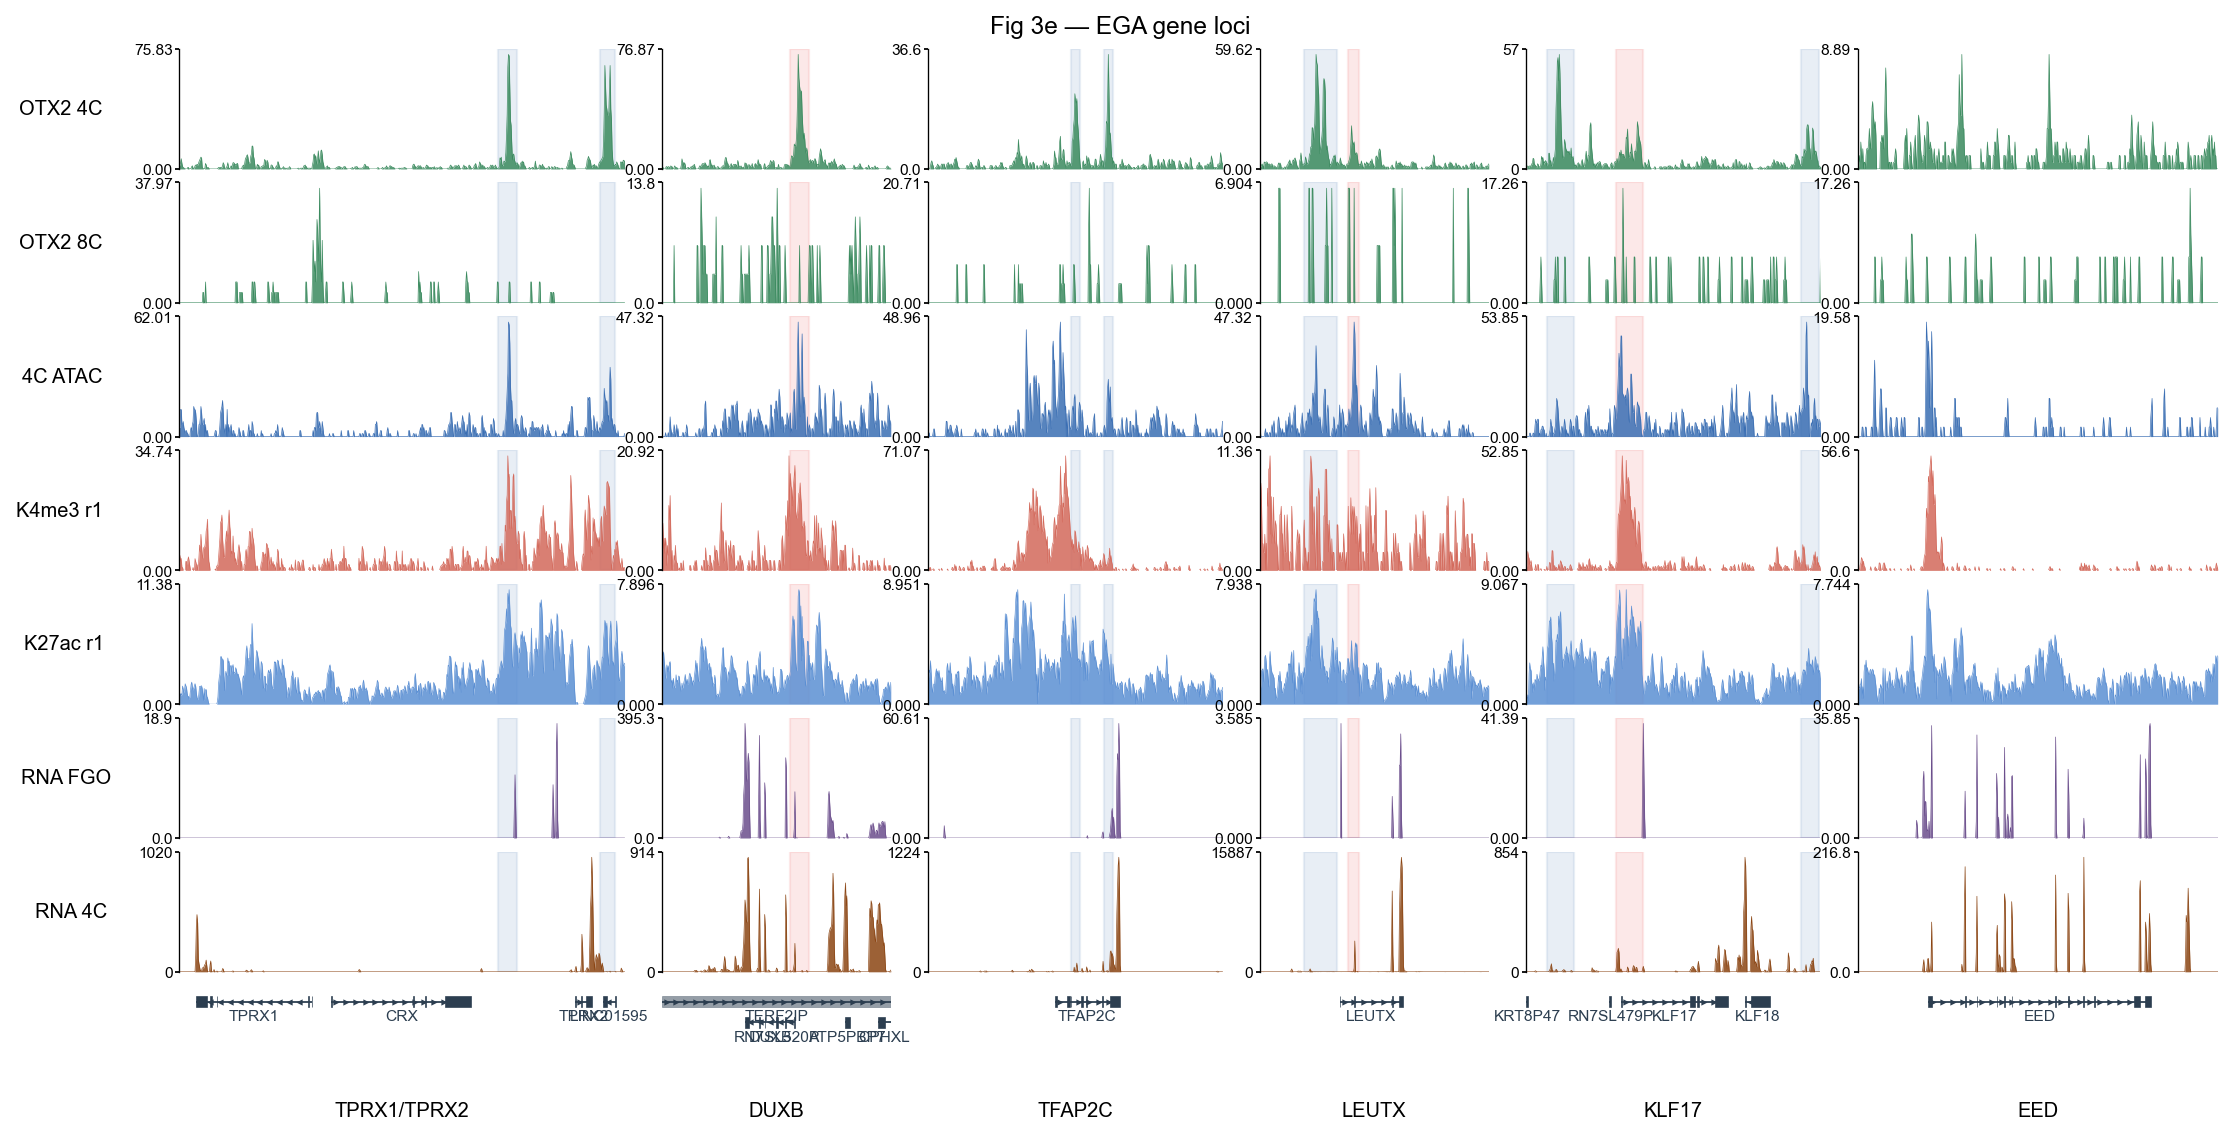

In [10]:
fig, axes = bw.plot_track_multi(
    LOCI, bw_names=TRACKS, color_dict=COLORS,
    figwidth=14, figheight=7,
    region_dict_by_locus=region_dict_by_locus,
    region_colors_by_locus=region_colors_by_locus,
    region_alpha=0.30,value_type='mean',
    title='Fig 3e — EGA gene loci')
plt.show()

## 3 · Signal heatmap across peak sets with `compute_matrix_region` + `plot_matrix_multi`

**Biological question.** Beyond hand-picked loci, is 4C OTX2 binding
systematically *different* from OTX2 binding in primed hESCs (ESC)
and in differentiated ectoderm-like cells (dEC)? If yes, that
supports the paper's claim that 4C OTX2 plays a stage-specific
regulatory role during minor EGA, separate from its known
pluripotency / ectoderm function.

The visual answer is a genome-wide heatmap: **one row per distal
peak, columns = ±3 kb signal window, grouped into cell-type-specific
and shared clusters**. Clusters that light up in 4C but stay dark in
ESC / dEC are the 4C-specific set.

The pipeline has three stages:
1. **§3.1** Load distal peak sets from three conditions (4C / ESC / dEC).
2. **§3.2** Partition the union of peaks into cell-type-specific vs shared clusters with `epi.utils.classify_peaks_by_overlap`.
3. **§3.3** Run `compute_matrix_region` per bigwig, then render all three matrices jointly with `plot_matrix_multi`.

### 3.1 · Load distal peak sets for three conditions

We need OTX2 peaks from three cell types:

| Set | Source | Filename on disk |
| --- | --- | --- |
| **4C** | Paper 4C CUT&RUN, rep1+rep2 merged MACS2 calls | `h_OTX2_day2_CUTRUN_rep12_peaks.bed` |
| **ESC** | Paper's H9 primed-hESC OTX2 ChIP | `H9_OTX2_ChIP_21Mcells_peaks.bed` |
| **dEC** | Gifford et al. 2013 differentiated ectoderm OTX2 ChIP | `GSM150570[7,10]_Otx2_*_ecto.bed.peak.txt.gz` — chromosome names lack the `chr` prefix, so we prepend it |

Then we restrict each set to **distal** peaks (≥ 2.5 kb from any
GENCODE TSS — paper convention) using
`epi.utils.filter_distal_peaks`. The paper motivates this: OTX2's
stage-specific role is at distal regulatory elements, not
housekeeping promoters. Dropping promoter-proximal peaks removes a
correlated nuisance signal before we cluster.

Under the hood, `filter_distal_peaks` builds a per-chromosome sorted
TSS array and uses `np.searchsorted` for O(log N) nearest-TSS
queries — fast enough for 100k peaks.

In [11]:
peaks_4C = pd.read_csv(OMIX / 'h_OTX2_day2_CUTRUN_rep12_peaks.bed',
                       sep='\t', header=None,
                       names=['chrom','start','end','name','score'])
peaks_4C = peaks_4C[['chrom','start','end']].astype({'start':int,'end':int})
peaks_ESC = pd.read_csv(OMIX / 'H9_OTX2_ChIP_21Mcells_peaks.bed',
                          sep='\t', header=None, usecols=[0,1,2], names=['chrom','start','end'])
dec_dfs = []
for f in [GIFFORD/'GSM1505707_Otx2_022813_ecto.bed.peak.txt.gz',
            GIFFORD/'GSM1505710_Otx2_062613_ecto.bed.peak.txt.gz']:
    d = pd.read_csv(f, sep='\t', header=None, usecols=[0,1,2],
                     names=['chrom','start','end'], dtype={'chrom':str})
    d['chrom'] = 'chr' + d['chrom']
    dec_dfs.append(d)
peaks_dEC = pd.concat(dec_dfs, ignore_index=True)
print(f'4C={len(peaks_4C)}  ESC={len(peaks_ESC)}  dEC={len(peaks_dEC)}')


4C=45521  ESC=70126  dEC=30714


In [12]:
# TSS annotation + distal peak filter via epi.utils.filter_distal_peaks
gtf = epi.utils.get_gene_annotation(str(GENCODE_GTF))
gtf['tss'] = np.where(gtf['strand']=='+', gtf['start'], gtf['end'])

distal_4C  = epi.utils.filter_distal_peaks(peaks_4C,  gtf[['chrom','tss']], min_distance=2500)
distal_ESC = epi.utils.filter_distal_peaks(peaks_ESC, gtf[['chrom','tss']], min_distance=2500)
distal_dEC = epi.utils.filter_distal_peaks(peaks_dEC, gtf[['chrom','tss']], min_distance=2500)
print(f'distal: 4C={len(distal_4C)} ESC={len(distal_ESC)} dEC={len(distal_dEC)}')

distal: 4C=41286 ESC=61892 dEC=22623


### 3.2 · Assign each peak to a cell-type-specific cluster

Three overlapping peak sets can partition into up to **seven**
clusters (`A-only`, `B-only`, `C-only`, `A∩B`, `A∩C`, `B∩C`,
`A∩B∩C`). For our heatmap each row of each matrix has to carry a
cluster label so the side-bar colour stripe lines up with the
signal.

### The function

`epi.utils.classify_peaks_by_overlap({set_name: peak_df}, primary_order=[...])`
returns a DataFrame where every peak in the *union* of the input
sets has a single `cluster` label summarising every set it overlaps
(e.g. `'4C-specific'`, `'4C/ESC shared'`, `'4C/ESC/dEC shared'`).

| Key parameter | What it controls |
| --- | --- |
| *dict* input | `{set_name: DataFrame_with_chrom_start_end}`. The first match dictates row provenance. |
| `primary_order` | tie-breaker. When a peak physically overlaps rows in two input sets, the function anchors it to the set listed first in `primary_order`. Here we use `['4C','ESC','dEC']` — 4C rows win ties, so "shared" clusters keep 4C genomic coordinates. |

Overlap is computed with a per-chromosome `searchsorted` interval
index (see `_build_interval_index` / `_overlaps_any` in
`epione.utils._sampling`) so the call scales cleanly to 100k+ peaks.

The returned DataFrame keeps a **stable, contiguous row order per
cluster** — that matters for §3.3, where each row's cluster label
must stay aligned with the signal matrix.

In [13]:
all_rows = epi.utils.classify_peaks_by_overlap(
    {'4C': distal_4C, 'ESC': distal_ESC, 'dEC': distal_dEC},
    primary_order=['4C','ESC','dEC'],
)
print(all_rows['cluster'].value_counts())

cluster
ESC-specific         43028
4C-specific          28209
dEC-specific         10081
4C/ESC shared         9722
ESC/dEC shared        5311
4C/ESC/dEC shared     2720
4C/dEC shared          635
Name: count, dtype: int64


### 3.3 · Compute signal matrices and render the heatmap

Three substeps inside one cell below:

**(a) Adapt `plot_rows` to the schema `compute_matrix_region` expects.**
The function is gene-oriented by default, so it expects columns
`seqname`, `start`, `end`, `strand`, `gene_id`, `feature`. Peaks
aren't genes, so we give every row a synthetic `gene_id`
(`peak_0`, `peak_1`, …) — this lets the function key its output
per-row.

**(b) Call `bw.compute_matrix_region(bw_name, regions, ...)` once per condition.**
Each call returns an `AnnData` with shape
`(len(regions), nbins)` of signal values.

| Key parameter | What it controls |
| --- | --- |
| `anchor` | where to centre the ±window. `'center'` uses each peak midpoint. Other options: `'5p'` / `'3p'` (strand-aware TSS/TES for genes), `'start'` / `'end'` (genomic coords), `'body'` (scaled gene body). |
| `nbins`, `upstream`, `downstream` | bin count and flank sizes. 120 bins × 6 kb total → 50-bp bins. |
| `sort` | **`False`** preserves the input row order. Needed here so cluster labels stay aligned; the default `True` would sort by signal. |
| `n_jobs` | per-chromosome multiprocessing. `4` is a good balance on a workstation. |

Under the hood, `compute_matrix_region` uses `pyBigWig.values()`
followed by a numpy `reshape` to aggregate to `nbins` bins in a
single call per region — roughly **80× faster** than calling
`pyBigWig.stats(..., nBins=N)` inside a loop.

**(c) Render with `bw.plot_matrix_multi(matrices, ...)`.**
Takes a `{condition: AnnData}` dict plus the per-row cluster labels
and renders a horizontal "three-block" heatmap with a coloured
cluster side-bar.

| Key parameter | What it controls |
| --- | --- |
| `cluster_labels` | aligned-with-rows vector naming each row's cluster. |
| `cluster_order` | display order of the cluster side-bar (top → bottom). |
| `cluster_colors` | `{cluster: colour}` — the side-bar stripe colour. |
| `figsize` | `(width, height)`. A tall thin figure (e.g. `(4.2, 7.5)`) is standard for ≥ 10k-row heatmaps. |

> **Performance tip.** The full distal union has ~100k peaks — enough
> to make every bigwig scan slow and the rendered heatmap visually
> indistinguishable from a 3000-per-cluster sample. We cap per-cluster
> rows (`MAX_PER_CLUSTER = 3000`) *before* calling
> `compute_matrix_region`.

### Reading the plot

- **4C-specific** cluster (green stripe): bright in 4C column, dark
  in ESC/dEC — these are the peaks the paper highlights as the
  OTX2 stage-specific EGA targets.
- **ESC-specific / dEC-specific**: mirror pattern (bright only in
  their own condition).
- **Shared clusters**: brighter in multiple columns — housekeeping
  OTX2 sites not specific to any one stage.

In [14]:
bw = epi.bulk.bigwig({
    '4C':  str(OMIX    / 'h_OTX2_day2_CUTRUN_rep12_pmu_100bp_rpkm_bamCoverage.bw'),
    'ESC': str(OMIX    / 'H9_OTX2_ChIP_21Mcells_100bp_rpkm_bamCoverage.bw'),
    'dEC': str(GIFFORD / 'GSM1505707_Otx2_022813_ecto.bw'),
})
bw.read()

# Cap each cluster at 3000 peaks BEFORE scanning — the full table has
# ~100k distal peaks; without the cap every bw scan is ~2 min.
MAX_PER_CLUSTER = 3000
plot_rows = (all_rows.groupby('cluster', sort=False, group_keys=False)
                     .apply(lambda g: g.head(MAX_PER_CLUSTER))
                     .reset_index(drop=True))

# Adapt peaks -> compute_matrix_region's expected schema.
regions = plot_rows.rename(columns={'chrom':'seqname'}).copy()
regions['strand']  = '+'
regions['feature'] = 'transcript'
regions['gene_id'] = [f'peak_{i}' for i in range(len(regions))]

# Compute signal matrix per condition (sort=False keeps row order
# aligned with plot_rows / cluster labels). n_jobs parallelises
# across chromosomes.
matrices = {
    name: bw.compute_matrix_region(
        name, regions, nbins=120, upstream=3000, downstream=3000,
        anchor='center', sort=False, n_jobs=4)
    for name in ['4C','ESC','dEC']
}
print({k: v.shape for k,v in matrices.items()})

└─ Load bigWig files
  ├─ Loading 4C...
  ├─ Loading ESC...
  └─ Loading dEC...


  └─ Computing 4C matrix (anchors=['center'])


Chromosomes:   0%|                                                                                               | 0/24 [00:00<?, ?chr/s]

Chromosomes:   4%|███▋                                                                                   | 1/24 [00:00<00:04,  4.77chr/s]

Chromosomes:  17%|██████████████▌                                                                        | 4/24 [00:00<00:01, 14.50chr/s]

...

Chromosomes:  58%|██████████████████████████████████████████████████▏                                   | 14/24 [00:00<00:00, 28.40chr/s]

Chromosomes:  75%|████████████████████████████████████████████████████████████████▌                     | 18/24 [00:00<00:00, 26.71chr/s]

Chromosomes: 100%|██████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 34.44chr/s]

Chromosomes: 100%|██████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 27.42chr/s]

  └─ dEC matrix finished
{'4C': (18355, 120), 'ESC': (18355, 120), 'dEC': (18355, 120)}


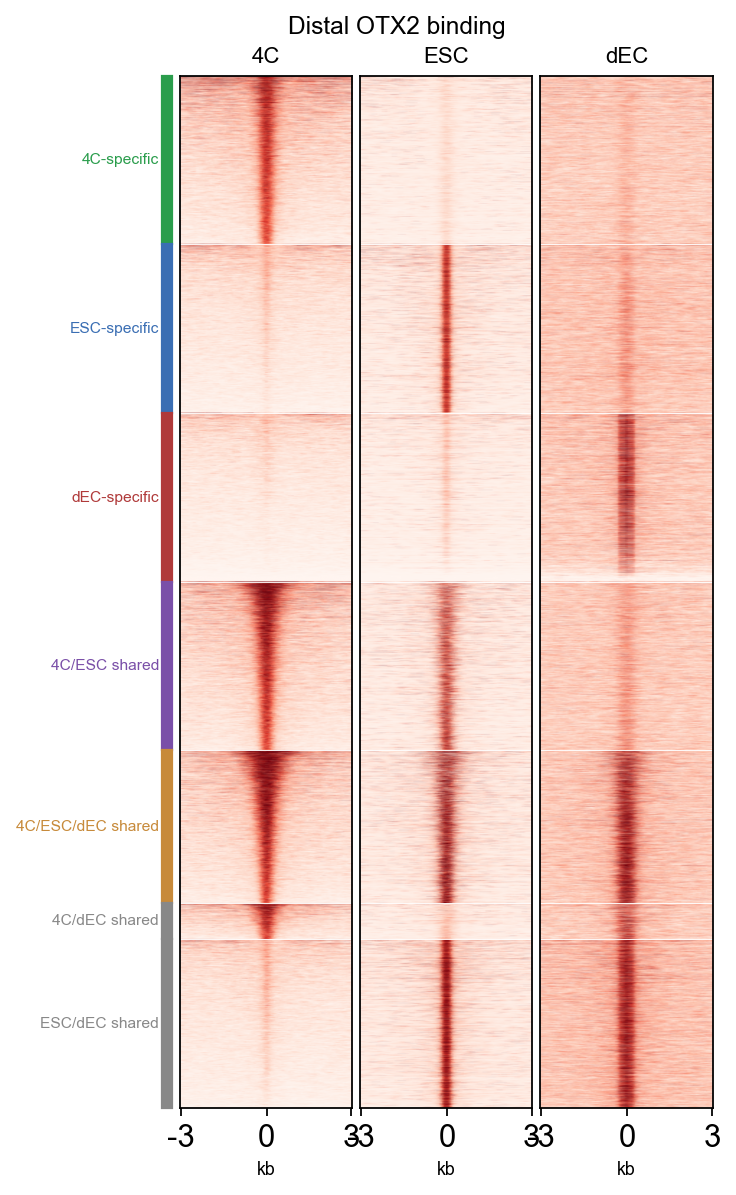

In [15]:
fig, axes = bw.plot_matrix_multi(
    matrices,
    cluster_labels=plot_rows['cluster'],
    cluster_order=['4C-specific','ESC-specific','dEC-specific',
                   '4C/ESC shared','4C/ESC/dEC shared'],
    cluster_colors={'4C-specific':'#2A9D4C','ESC-specific':'#3A6EB3',
                    'dEC-specific':'#B03A3A','4C/ESC shared':'#7A4FA8',
                    '4C/ESC/dEC shared':'#C78A3A'},
    figsize=(4.2, 7.5), title='Distal OTX2 binding',
)
plt.show()

## 4 · TF motif enrichment with `find_motifs_genome`

**Biological question.** 4C OTX2 binds tens of thousands of peaks.
Does the DNA under those peaks carry motifs for **other** TFs?
Co-enrichment hints at cooperative or partner TFs that might act
with OTX2 during EGA. The paper's top hits are OTX2 itself
(positive control), plus its homeodomain paralogues (GSC, CRX,
PITX1, PHOX2A).

### The function

`epi.bulk.find_motifs_genome(peaks, genome, motif_library, ...)` is a
pure-Python, GPU-accelerated drop-in replacement for HOMER's
`findMotifsGenome.pl`. Same inputs, same statistical model
(right-tailed binomial on target-vs-background PWM hit frequencies),
same output directory layout.

Pipeline inside the call:

1. **Extract sequences** — read ±`size/2` bp around each peak centre from the reference FASTA.
2. **Sample GC-matched background** — `n_bg` random genomic windows of the same size, stratified by GC content so the null accounts for local base composition.
3. **Scan every PWM against both sets on GPU** — one-hot encode sequences, run `torch.nn.functional.conv1d` in batches, threshold against each PWM's log-odds cutoff.
4. **Binomial tail test** — target-hit fraction vs background-hit fraction. Uses `mpmath.betainc` for extreme tails where `scipy.stats.binom.logsf` underflows.

| Key parameter | What it controls |
| --- | --- |
| `peaks` | DataFrame with `chrom/start/end` (or a BED path). |
| `genome` | reference FASTA path (e.g. `hg19.fa`) — pyfaidx-indexed on the fly. |
| `motif_library` | HOMER `.motifs` file. We use the bundled `knownTFs/vertebrates/known.motifs`. |
| `size` | window size in bp centred on each peak (HOMER default: 200). |
| `n_bg` | number of GC-matched random-genomic background windows (50 000 gives stable p-values at ≥ 10⁻³). |
| `backend` | `'auto'` uses GPU via `torch.cuda` if available, else falls back to CPU multiprocessing. |
| `seed` | RNG seed for reproducible backgrounds. |
| `outdir` | writes a HOMER-compatible directory (`knownResults.txt` + PWM logos) so any HOMER downstream tool still works. |

Performance: ~150 s for 95k peaks × 429 TFs on an H100, vs ~15 min
for the Perl pipeline on comparable hardware.

### Rendering

`epi.pl.homer_motif_table(outdir, top_n=5, collapse_per_tf=True)`
reads the HOMER-shaped output directory and draws the familiar
"top motifs" figure: PWM sequence logo + TF name + log₁₀(P-value)
per row.

| Key parameter | What it controls |
| --- | --- |
| `outdir` | directory written by `find_motifs_genome` (or HOMER). |
| `top_n` | how many rows to show. 5 is the paper's choice. |
| `collapse_per_tf` | keep only the best motif per TF. HOMER often lists multiple motifs for the same TF (slightly different PWMs); this deduplicates the table. |

### Reading the output

Expect **OTX2** on top (sanity check: we pulled down OTX2, so its
own motif should be the most enriched), followed by its homeodomain
paralogues — the paper's Fig 3b lists OTX2, GSC, DUX4, CRX, PHOX2A.
Our pure-Python backend should reproduce the same ranking (exact p-
values differ by a constant factor due to binomial-tail precision
differences, but the ordering and % target / % background columns
match HOMER).

In [16]:
MOTIF_DB = pathlib.Path('/scratch/users/steorra/env/omicdev/share/homer/data/knownTFs/vertebrates/known.motifs')
HOMER_OUT = pathlib.Path('/tmp/otx2_compare/fig3b/homer_out_py')

In [17]:
peaks = pd.read_csv(OMIX / 'h_OTX2_day2_CUTRUN_rep12_peaks.bed',
                    sep='\t', header=None,
                    names=['chrom','start','end','name','score'])

enrich = epi.bulk.find_motifs_genome(
    peaks, genome=HG19_FA, motif_library=MOTIF_DB,
    size=200, n_bg=50_000, seed=0,
    backend='auto',          # GPU if torch.cuda available, else CPU mp
    outdir=HOMER_OUT,        # writes HOMER-shaped knownResults + PWMs
    verbose=False,
)
enrich.head(5)[['Motif Name','Log P-value',
                      '% of Target Sequences with Motif',
                      '% of Background Sequences with Motif']]


,Motif Name,Log P-value,% of Target Sequences with Motif,% of Background Sequences with Motif
0,Otx2(Homeobox)/EpiLC-Otx2-ChIP-Seq(GSE56098)/H...,-21961.359337,39.834362,10.160203
1,GSC(Homeobox)/FrogEmbryos-GSC-ChIP-Seq(DRA0005...,-13890.270493,53.474221,21.426429
2,CRX(Homeobox)/Retina-Crx-ChIP-Seq(GSE20012)/Homer,-11583.771207,67.215131,33.540671
3,Pitx1(Homeobox)/Chicken-Pitx1-ChIP-Seq(GSE3891...,-5654.047782,78.049691,53.191064
4,Mixl1(Homeobox)/EpiBlast-Mixl1-ChIP-seq(GSE161...,-2787.942285,17.745656,8.168163


   TF                                               Motif Name       log10P
 OTX2       Otx2(Homeobox)/EpiLC-Otx2-ChIP-Seq(GSE56098)/Homer -9537.697175
  GSC  GSC(Homeobox)/FrogEmbryos-GSC-ChIP-Seq(DRA000576)/Homer -6032.467827
  CRX        CRX(Homeobox)/Retina-Crx-ChIP-Seq(GSE20012)/Homer -5030.767915
PITX1   Pitx1(Homeobox)/Chicken-Pitx1-ChIP-Seq(GSE38910)/Homer -2455.521752
MIXL1 Mixl1(Homeobox)/EpiBlast-Mixl1-ChIP-seq(GSE161164)/Homer -1210.787950


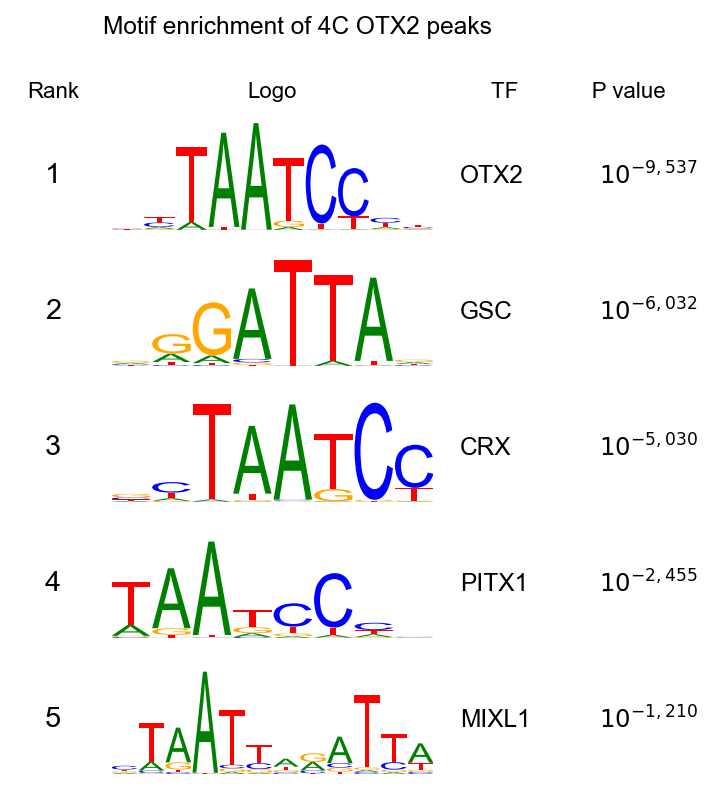

In [18]:
fig, axes, top = epi.pl.homer_motif_table(
    HOMER_OUT, top_n=5, collapse_per_tf=True,
    title='Motif enrichment of 4C OTX2 peaks',
)
print(top[['TF','Motif Name','log10P']].to_string(index=False))